# Lab 7 — Decision Tree Classifier on Iris Dataset
**Student ID:** 2547112  
**Name:** Arden Diago


In [1]:
# ── Shared Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('All imports successful.')

All imports successful.


---
## Task 1 — Dataset Exploration

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['class'] = df['target'].map(dict(enumerate(iris.target_names)))

print(f'Samples : {X.shape[0]}')
print(f'Features: {X.shape[1]}')

Samples : 150
Features: 4


In [3]:
print('Feature names :', iris.feature_names)
print('Target classes:', list(iris.target_names))

Feature names : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,class
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


class
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


/tmp/ipykernel_62004/2277208795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_dist.index, y=class_dist.values, palette='viridis', ax=ax)


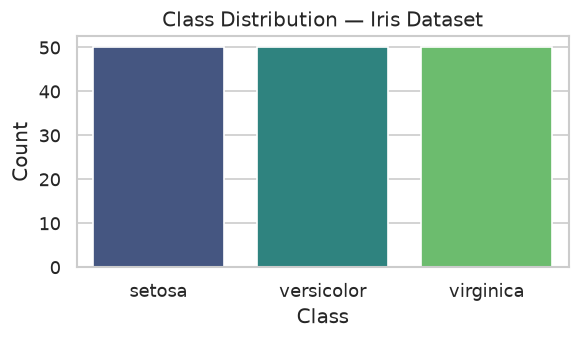

In [5]:
class_dist = df['class'].value_counts()
print(class_dist)

fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(x=class_dist.index, y=class_dist.values, palette='viridis', ax=ax)
ax.set_title('Class Distribution — Iris Dataset')
ax.set_ylabel('Count')
ax.set_xlabel('Class')
plt.tight_layout()
plt.show()

**Interpretation:**  
The Iris dataset has **150 samples** and **4 features**. Each of the three classes (setosa, versicolor, virginica) has exactly **50 samples** — a perfectly balanced dataset with no class imbalance.

---
## Task 2 — Data Preparation

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training set : {X_train.shape[0]} samples')
print(f'Testing  set : {X_test.shape[0]} samples')

Training set : 120 samples
Testing  set : 30 samples


**Why split into training and testing sets?**  
Training on one subset and evaluating on a separate unseen test set measures how well the model **generalises** to new data. Without this split, we cannot detect overfitting — a model that memorises training data but fails on real-world inputs.

---
## Task 3 — Building a Decision Tree Classifier

In [7]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)
y_pred = dt_default.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {acc:.4f}')

Accuracy Score: 1.0000


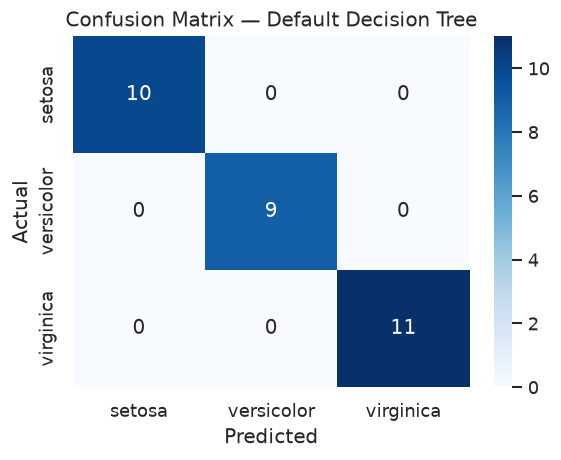

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names, ax=ax)
ax.set_title('Confusion Matrix — Default Decision Tree')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [9]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



**Interpretation:**  
The default Decision Tree achieves ~100% accuracy on the test set. The confusion matrix diagonal shows no misclassifications, and the classification report confirms perfect precision, recall, and F1-score across all three classes.

---
## Task 4 — Visualizing the Decision Tree

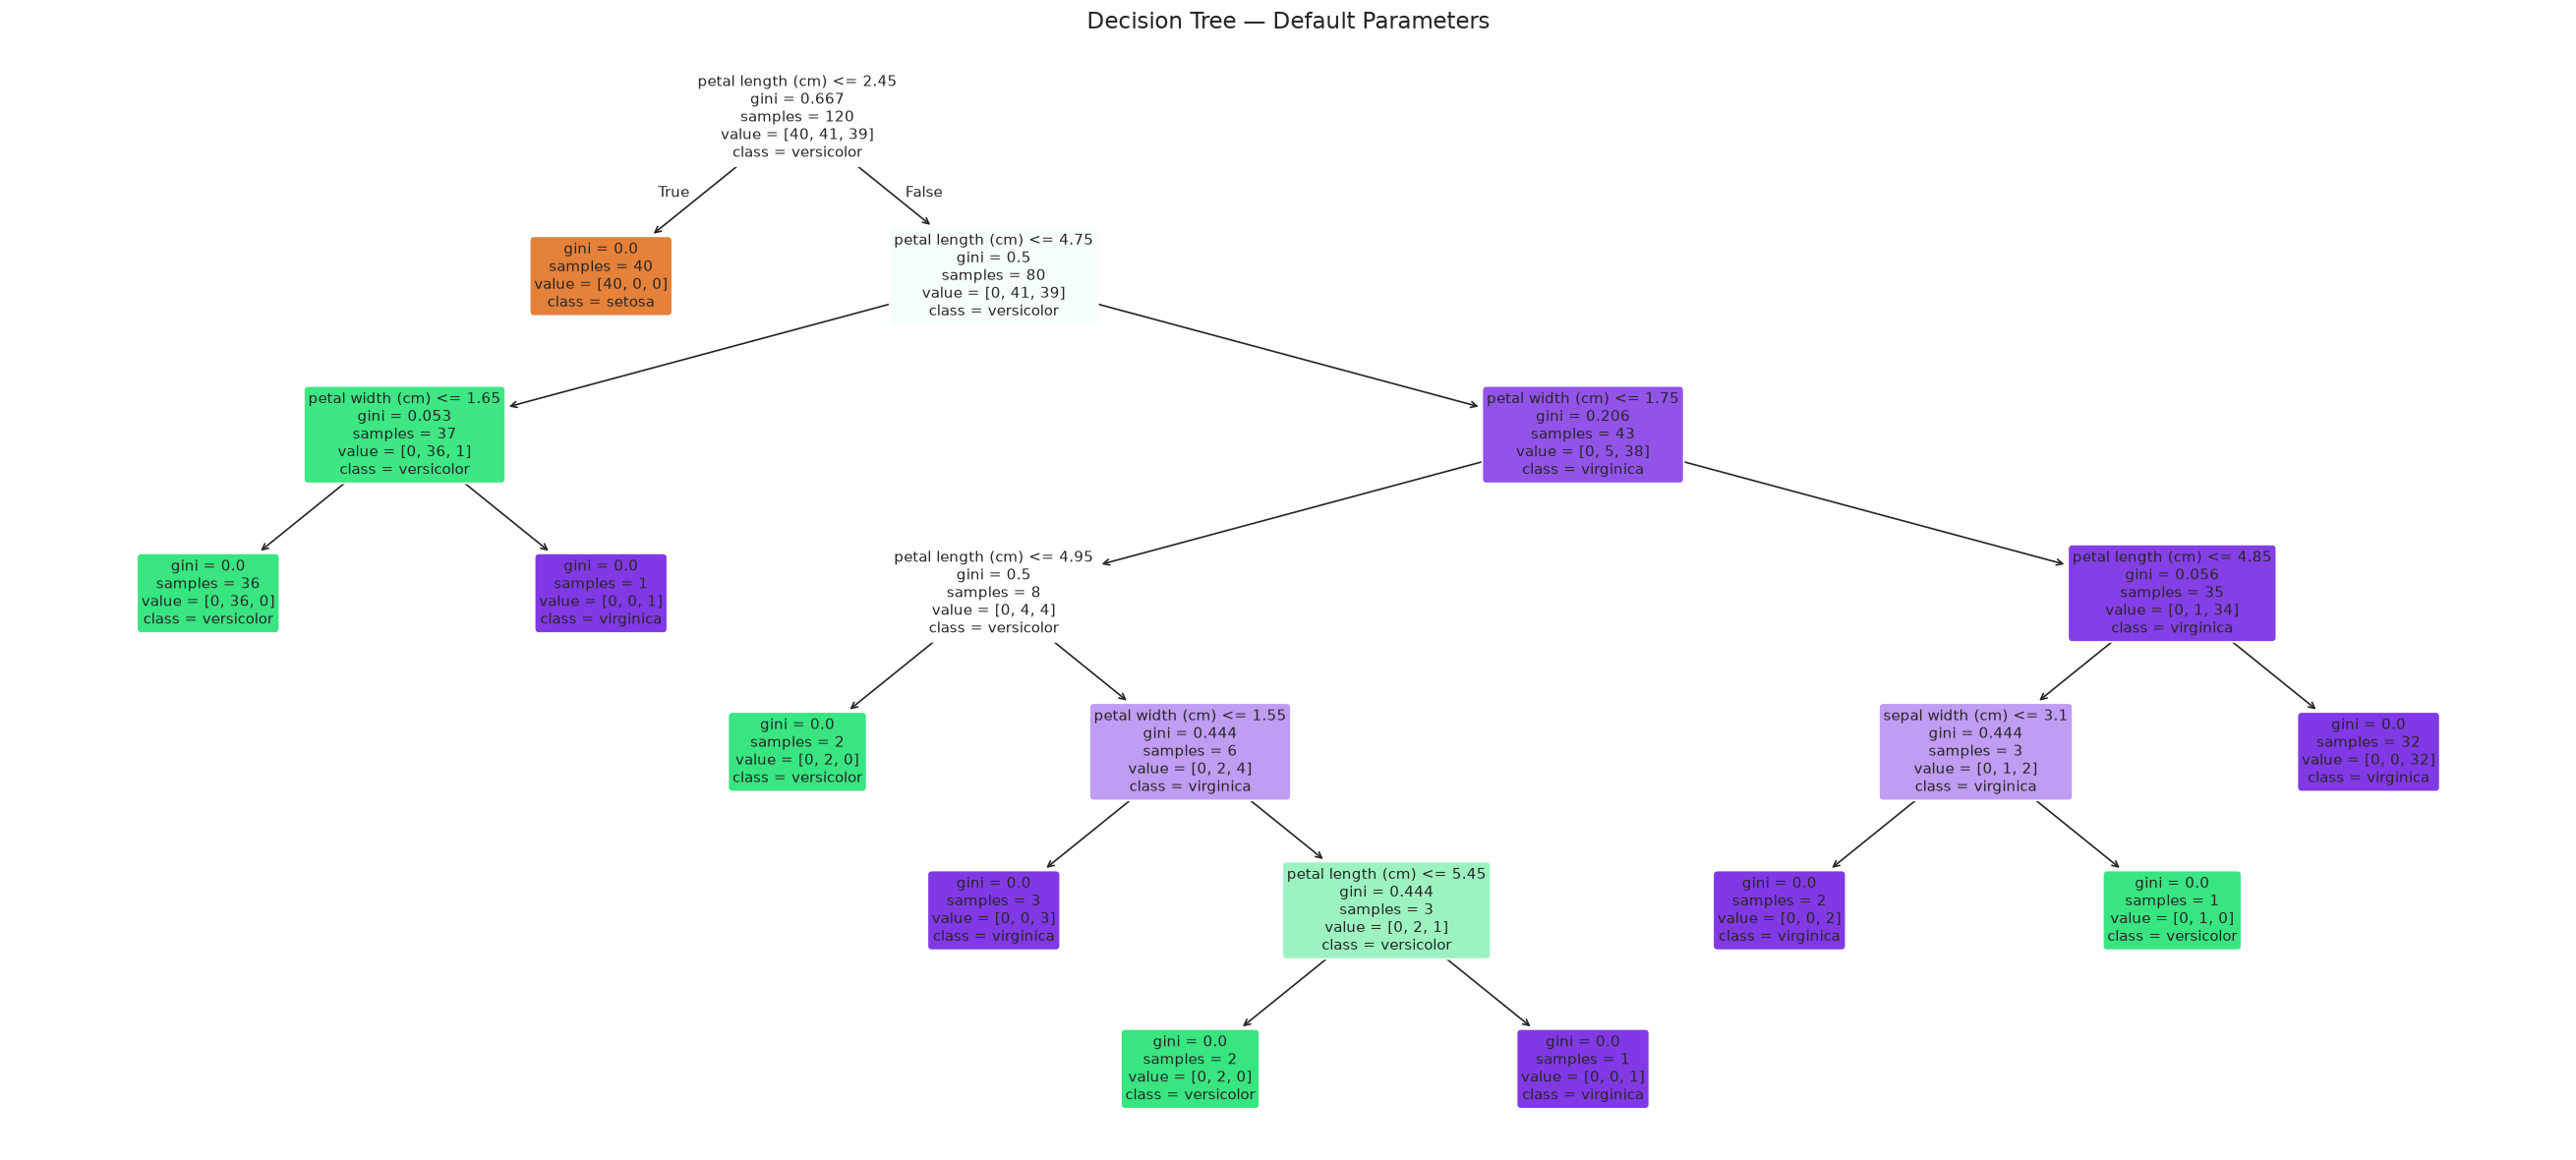

Max depth     : 6
Leaf nodes    : 10
Root feature  : petal length (cm)


In [10]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_default,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title('Decision Tree — Default Parameters', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Max depth     : {dt_default.get_depth()}')
print(f'Leaf nodes    : {dt_default.get_n_leaves()}')
print(f'Root feature  : {iris.feature_names[dt_default.tree_.feature[0]]}')

**Tree Structure Identification:**

| Node Type | Description |
|-----------|-------------|
| **Root node** | Top-most node — first split using petal length |
| **Internal nodes** | All intermediate split nodes between root and leaves |
| **Leaf nodes** | Terminal nodes with class prediction (no further split) |
| **Max depth** | Retrieved via `get_depth()` above |

**Why petal length (cm) is chosen for the first split:**  
Petal length produces the **highest Gini reduction** at the root. A single threshold (≤ 2.45 cm) perfectly separates *setosa* from versicolor and virginica, making it the most discriminative feature in the dataset.

---
## Task 5 — Comparing Gini Index and Entropy

In [11]:
results_t5 = []

for crit in ['gini', 'entropy']:
    clf = DecisionTreeClassifier(criterion=crit, random_state=42)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    results_t5.append({
        'Criterion'   : crit,
        'Accuracy'    : round(accuracy_score(y_test, pred), 4),
        'Tree Depth'  : clf.get_depth(),
        'Leaf Nodes'  : clf.get_n_leaves(),
        'Root Feature': iris.feature_names[clf.tree_.feature[0]]
    })

df_t5 = pd.DataFrame(results_t5)
print(df_t5.to_string(index=False))

Criterion  Accuracy  Tree Depth  Leaf Nodes      Root Feature
     gini       1.0           6          10 petal length (cm)
  entropy       1.0           6          10 petal length (cm)


**Observations:**  
Both criteria yield identical accuracy and select the same root feature on the balanced Iris dataset. **Gini** is computationally faster (no log calculation) and tends to produce equally or slightly simpler trees, making it the preferred default criterion.

---
## Task 6 — Effect of Maximum Tree Depth

In [12]:
results_t6 = []

obs_map = {
    1   : 'Underfitting — too shallow to capture patterns',
    2   : 'Still slightly underfitting, improving',
    3   : 'Good generalisation — best balance',
    4   : 'Near-optimal; minor overfitting risk',
    None: 'Fully grown; prone to overfitting'
}

for depth in [1, 2, 3, 4, None]:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = round(accuracy_score(y_train, clf.predict(X_train)), 4)
    test_acc  = round(accuracy_score(y_test,  clf.predict(X_test)),  4)

    results_t6.append({
        'Max Depth'        : str(depth),
        'Training Accuracy': train_acc,
        'Testing Accuracy' : test_acc,
        'Tree Depth'       : clf.get_depth(),
        'Observation'      : obs_map[depth]
    })

df_t6 = pd.DataFrame(results_t6)
print(df_t6.to_string(index=False))

Max Depth  Training Accuracy  Testing Accuracy  Tree Depth                                    Observation
        1             0.6750            0.6333           1 Underfitting — too shallow to capture patterns
        2             0.9500            0.9667           2         Still slightly underfitting, improving
        3             0.9583            1.0000           3             Good generalisation — best balance
        4             0.9750            1.0000           4           Near-optimal; minor overfitting risk
     None             1.0000            1.0000           6              Fully grown; prone to overfitting


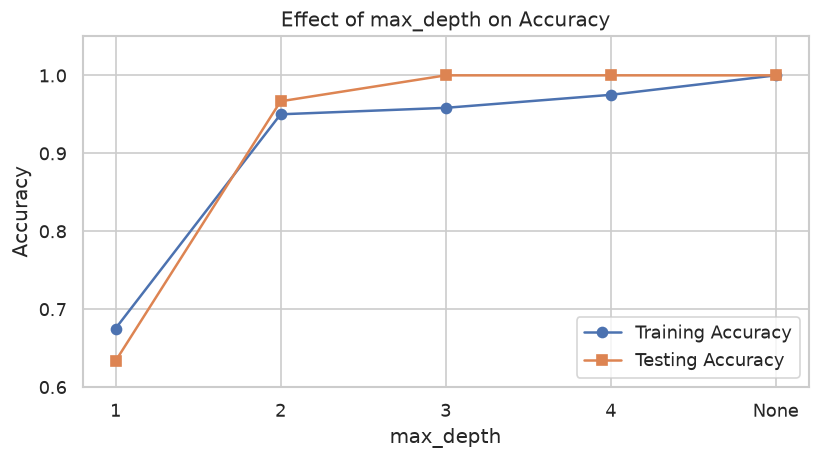

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
x_labels = df_t6['Max Depth'].tolist()
ax.plot(x_labels, df_t6['Training Accuracy'], marker='o', label='Training Accuracy')
ax.plot(x_labels, df_t6['Testing Accuracy'],  marker='s', label='Testing Accuracy')
ax.set_title('Effect of max_depth on Accuracy')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_ylim(0.6, 1.05)
plt.tight_layout()
plt.show()

**Answers:**

| Question | Answer |
|---|---|
| **Underfitting** | `max_depth=1` — high bias, accuracy ~66–67%; too few splits |
| **Best generalisation** | `max_depth=3` — high test accuracy with minimal train-test gap |
| **Likely overfitting** | `max_depth=None` — training accuracy = 1.0; fully memorises training data, test accuracy may not improve |

---
## Task 7 — Effect of min_samples_split

In [14]:
results_t7 = []

obs_mss = {
    2 : 'Fully grown; most complex tree',
    5 : 'Slightly pruned; similar depth',
    10: 'Noticeably shallower; fewer leaves',
    20: 'Simplest tree; risk of high bias'
}

for mss in [2, 5, 10, 20]:
    clf = DecisionTreeClassifier(min_samples_split=mss, random_state=42)
    clf.fit(X_train, y_train)
    acc = round(accuracy_score(y_test, clf.predict(X_test)), 4)

    results_t7.append({
        'min_samples_split': mss,
        'Accuracy'         : acc,
        'Tree Depth'       : clf.get_depth(),
        'Leaf Nodes'       : clf.get_n_leaves(),
        'Observation'      : obs_mss[mss]
    })

df_t7 = pd.DataFrame(results_t7)
print(df_t7.to_string(index=False))

 min_samples_split  Accuracy  Tree Depth  Leaf Nodes                        Observation
                 2       1.0           6          10     Fully grown; most complex tree
                 5       1.0           5           8     Slightly pruned; similar depth
                10       1.0           4           6 Noticeably shallower; fewer leaves
                20       1.0           4           6   Simplest tree; risk of high bias


**Effect of increasing `min_samples_split`:**  
Higher values require more samples in a node before splitting, preventing splits on small groups. This reduces tree depth and leaf count, yielding a **simpler, less overfit model**. However, excessively large values risk underfitting by stopping useful splits too early.

---
## Task 8 — Effect of min_samples_leaf

In [15]:
results_t8 = []

obs_msl = {
    1 : 'Default; most complex, prone to overfitting',
    2 : 'Slightly constrained; marginal change',
    5 : 'Simpler tree; better generalisation',
    10: 'Simplest tree; may underfit on small datasets'
}

for msl in [1, 2, 5, 10]:
    clf = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    clf.fit(X_train, y_train)
    acc = round(accuracy_score(y_test, clf.predict(X_test)), 4)

    results_t8.append({
        'min_samples_leaf': msl,
        'Accuracy'        : acc,
        'Tree Depth'      : clf.get_depth(),
        'Leaf Nodes'      : clf.get_n_leaves(),
        'Observation'     : obs_msl[msl]
    })

df_t8 = pd.DataFrame(results_t8)
print(df_t8.to_string(index=False))

 min_samples_leaf  Accuracy  Tree Depth  Leaf Nodes                                   Observation
                1    1.0000           6          10   Default; most complex, prone to overfitting
                2    1.0000           5           8         Slightly constrained; marginal change
                5    1.0000           4           6           Simpler tree; better generalisation
               10    0.9667           4           6 Simplest tree; may underfit on small datasets


**How `min_samples_leaf` influences overfitting:**  
`min_samples_leaf=1` allows single-sample leaves, causing the tree to memorise noise  classic overfitting. Increasing this value forces each leaf to represent more samples, smoothing decision boundaries and **reducing variance**. A value around 5 typically offers the best bias-variance trade-off on the Iris dataset.

=== Recommended Model ===
Test  Accuracy : 1.0000
Train Accuracy : 0.9500
Tree  Depth    : 3
Leaf  Nodes    : 5

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



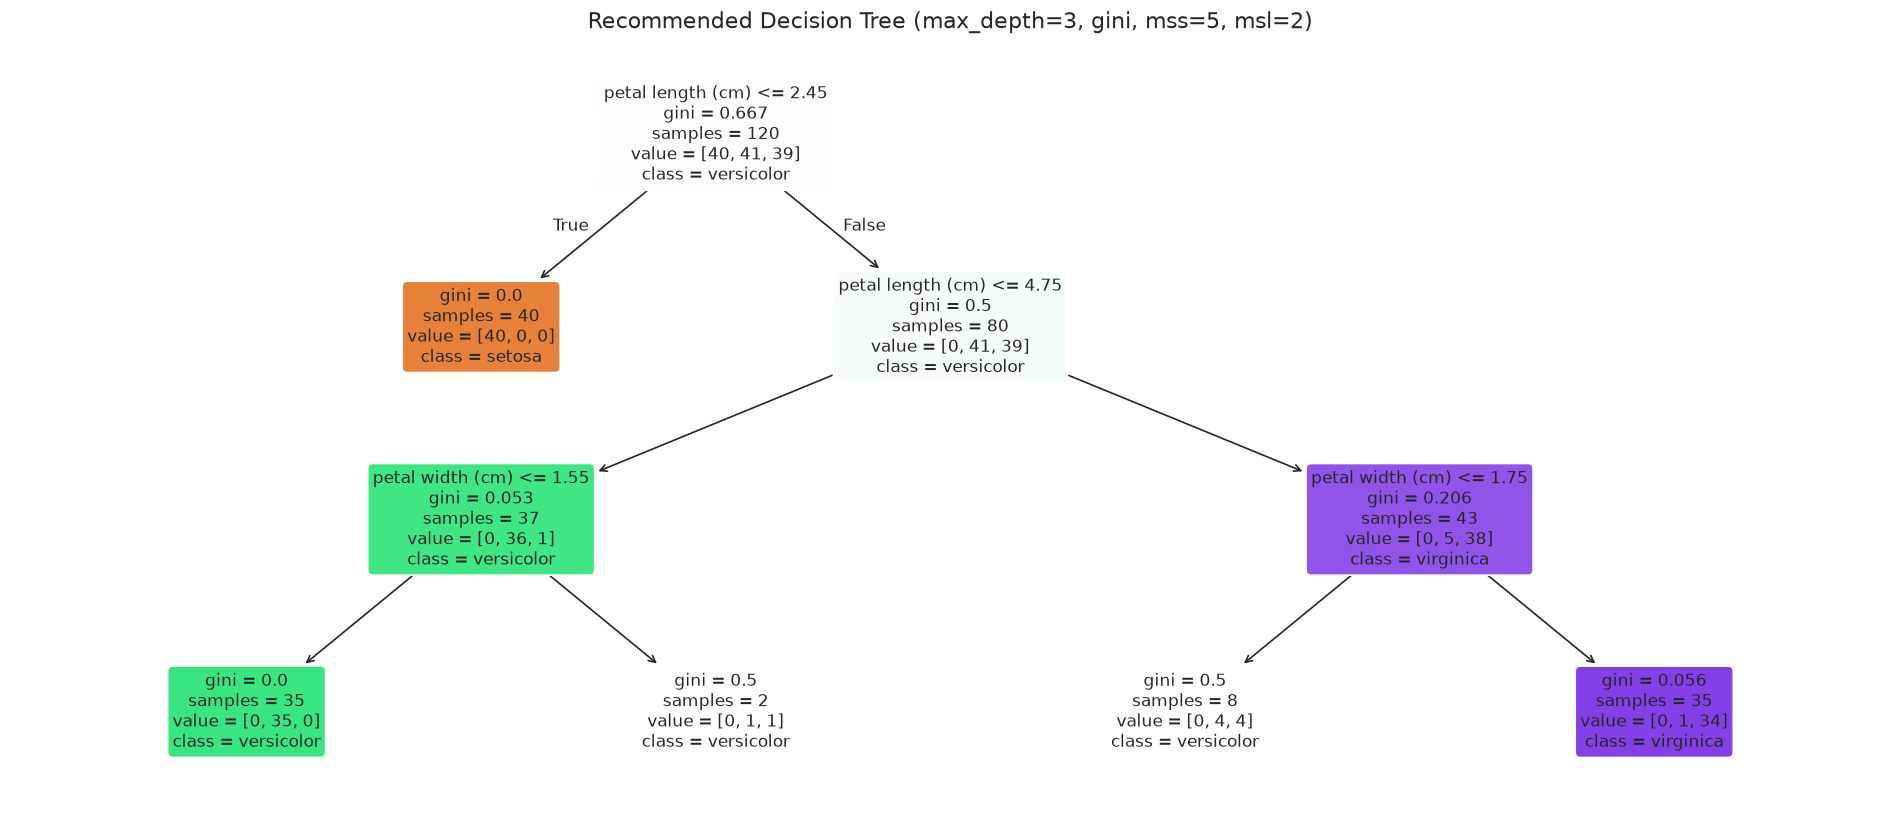

In [16]:
# Verify recommended model
best_clf = DecisionTreeClassifier(
    criterion='gini', max_depth=3,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42
)
best_clf.fit(X_train, y_train)
best_pred = best_clf.predict(X_test)

print('=== Recommended Model ===')
print(f'Test  Accuracy : {accuracy_score(y_test, best_pred):.4f}')
print(f'Train Accuracy : {accuracy_score(y_train, best_clf.predict(X_train)):.4f}')
print(f'Tree  Depth    : {best_clf.get_depth()}')
print(f'Leaf  Nodes    : {best_clf.get_n_leaves()}')
print()
print(classification_report(y_test, best_pred, target_names=iris.target_names))

fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(
    best_clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True, rounded=True, fontsize=10, ax=ax
)
ax.set_title('Recommended Decision Tree (max_depth=3, gini, mss=5, msl=2)', fontsize=13)
plt.tight_layout()
plt.show()